### Change of Mind
### scaled up analysis from 1.1

### 2. Plot Decoding around Change Of Mind time

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
from ripple_detection.core import segment_boolean_series

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2025-10-30 11:27:10,696][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,MUA,get_linearization_map
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.ripple_add_replay import plot_decode_spiking
from spyglass.shijiegu.changeOfMind import (
            find_trials, load_epoch_data_wrapper, find_trials_animal)

[11:27:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:27:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:27:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:27:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

In [ ]:
animal = 'Lewis'
dates_to_plot = ['20240113']#['20240106','20240107','20240108','20240109',
                # '20240110','20240113']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [ ]:
animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221018','20221019','20221020','20221021','20221022']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [ ]:
animal = 'Haydn'
dates_to_plot = ['20230603','20230604','20230605','20230606','20230607','20230608']
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [ ]:
animal = 'Molly'
dates_to_plot = ['20220418']
datafolder = f'/stelmo/shijie/behavior_pilot/Batch1/{animal}'

In [ ]:
animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221021']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

In [ ]:
animal = 'Klein'
dates_to_plot = ['20231107']
datafolder = f'/stelmo/shijie/behavior_pilot/Batch1/{animal}'

In [14]:
animal = 'Julio'
dates_to_plot = ['20230808']
datafolder = f'/stelmo/shijie/behavior_pilot/Batch1/{animal}'

[14:23:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:23:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


[14:23:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-30 14:23:10,991][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2025-10-30 14:23:11,009][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2025-10-30 14:23:11,014][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb


currently investigating:
02_Seq2Session1
pos 1 valid times


[2025-10-30 14:23:20,170][WARNING]: Skipped checksum for file with hash: 37098ac7-e1e1-a0ef-9f72-8d15c56d02bf, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_FEUCU1G9X6.nwb
[2025-10-30 14:23:20,192][WARNING]: Skipped checksum for file with hash: 37098ac7-e1e1-a0ef-9f72-8d15c56d02bf, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_FEUCU1G9X6.nwb
[2025-10-30 14:23:20,198][WARNING]: Skipped checksum for file with hash: 37098ac7-e1e1-a0ef-9f72-8d15c56d02bf, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_FEUCU1G9X6.nwb
[2025-10-30 14:23:29,317][WARNING]: Skipped checksum for file with hash: 328586bf-022e-fb9a-008e-2f32655f2e81, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_IIXWEKI64R.nwb
[2025-10-30 14:23:38,138][WARNING]: Skipped checksum for file with hash: 584f727d-e706-2dd4-1d8a-949df94bedad, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_BF5L5RLVOS.nwb
[2025-10-30 14:23:38,157][WARNING]: Skipped checksum for file with hash: 58

len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
rowID [20 37 41 67]
epoch name 02_Seq2Session1
epoch_pos_name pos 1 valid times


[2025-10-30 14:23:47,297][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2025-10-30 14:23:47,316][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2025-10-30 14:23:47,322][WARNING]: Skipped checksum for file with hash: 16529eb1-df1e-dfea-91ee-fb5bbedb9e82, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MIWP9GUTZY.nwb
[2025-10-30 14:23:47,444][WARNING]: Skipped checksum for file with hash: 47747f36-635c-8515-4140-11a2cb9335ba, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_HAA7GRNNCR.nwb
[2025-10-30 14:23:47,463][WARNING]: Skipped checksum for file with hash: 47747f36-635c-8515-4140-11a2cb9335ba, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_HAA7GRNNCR.nwb
[2025-10-30 14:23:47,469][WARNING]: Skipped checksum for file with hash: 47

...

[2025-10-30 14:27:42,422][WARNING]: Skipped checksum for file with hash: 6666af5a-a916-4c0a-83ad-e2af804dc405, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_U2X80ZPYUF.nwb
[2025-10-30 14:27:42,441][WARNING]: Skipped checksum for file with hash: 6666af5a-a916-4c0a-83ad-e2af804dc405, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_U2X80ZPYUF.nwb
[2025-10-30 14:27:42,447][WARNING]: Skipped checksum for file with hash: 6666af5a-a916-4c0a-83ad-e2af804dc405, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_U2X80ZPYUF.nwb
[2025-10-30 14:27:42,554][WARNING]: Skipped checksum for file with hash: 47747f36-635c-8515-4140-11a2cb9335ba, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_HAA7GRNNCR.nwb
[2025-10-30 14:27:42,573][WARNING]: Skipped checksum for file with hash: 47747f36-635c-8515-4140-11a2cb9335ba, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_HAA7GRNNCR.nwb
[2025-10-30 14:27:42,578][WARNING]: Skipped checksum for file with hash: 47

currently investigating:
08_Seq2Session4
pos 7 valid times


[2025-10-30 14:29:10,252][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb
[2025-10-30 14:29:10,269][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb
[2025-10-30 14:29:10,273][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb
[2025-10-30 14:29:19,445][WARNING]: Skipped checksum for file with hash: 4c3bb2a6-7842-14bc-b264-b7c2c4e806ac, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_8CM7Q91QU4.nwb
[2025-10-30 14:29:28,403][WARNING]: Skipped checksum for file with hash: db9fc61b-ab0a-1bb5-1f16-e7e1a47939e0, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_C3YXPYSWK0.nwb
[2025-10-30 14:29:28,422][WARNING]: Skipped checksum for file with hash: db

len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
rowID [27 34 66]
epoch name 08_Seq2Session4
epoch_pos_name pos 7 valid times


[2025-10-30 14:29:37,552][WARNING]: Skipped checksum for file with hash: 48a5386a-75bf-3a72-ee45-719939b44ede, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_KKYSXWV1TW.nwb
[2025-10-30 14:29:37,573][WARNING]: Skipped checksum for file with hash: 48a5386a-75bf-3a72-ee45-719939b44ede, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_KKYSXWV1TW.nwb
[2025-10-30 14:29:37,579][WARNING]: Skipped checksum for file with hash: 48a5386a-75bf-3a72-ee45-719939b44ede, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_KKYSXWV1TW.nwb
[2025-10-30 14:29:37,674][WARNING]: Skipped checksum for file with hash: 47747f36-635c-8515-4140-11a2cb9335ba, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_HAA7GRNNCR.nwb
[2025-10-30 14:29:37,693][WARNING]: Skipped checksum for file with hash: 47747f36-635c-8515-4140-11a2cb9335ba, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_HAA7GRNNCR.nwb
[2025-10-30 14:29:37,698][WARNING]: Skipped checksum for file with hash: 47

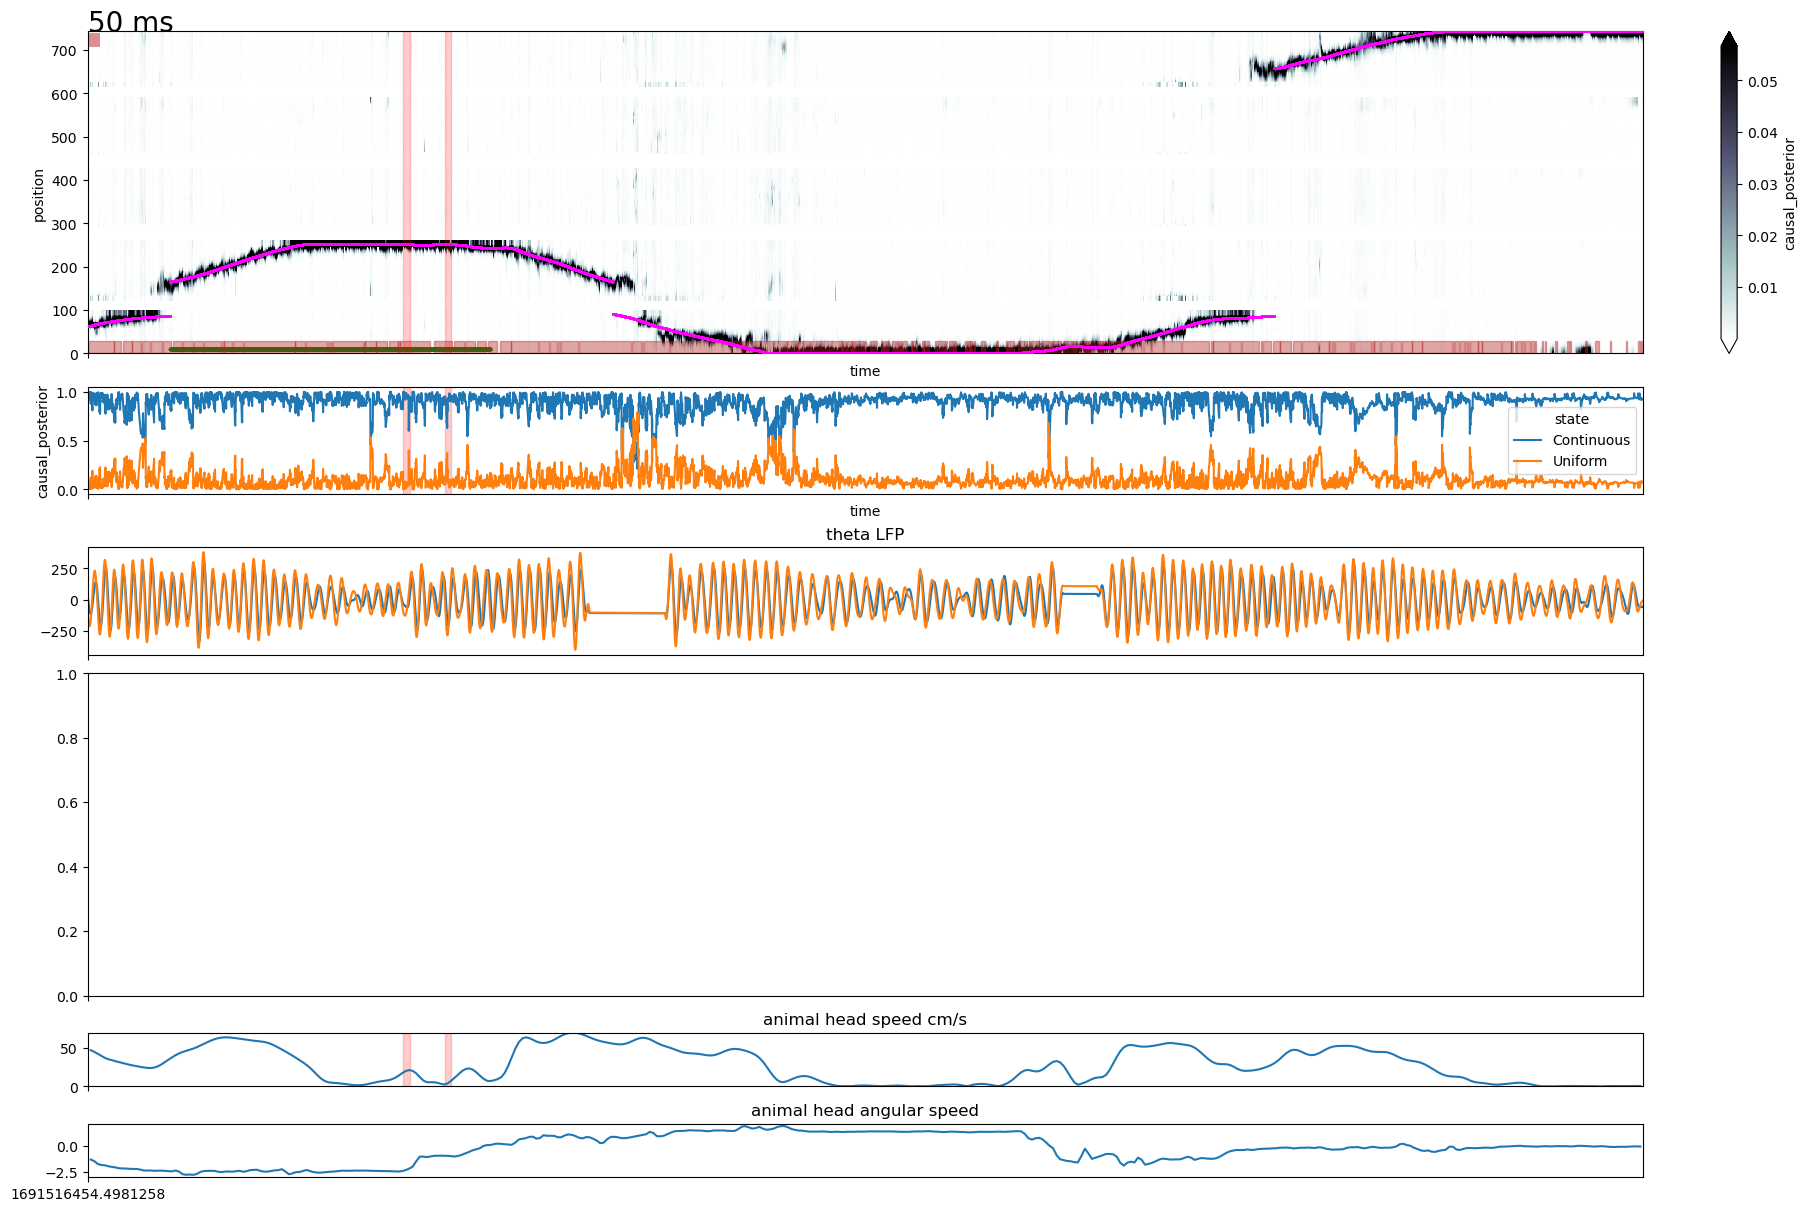

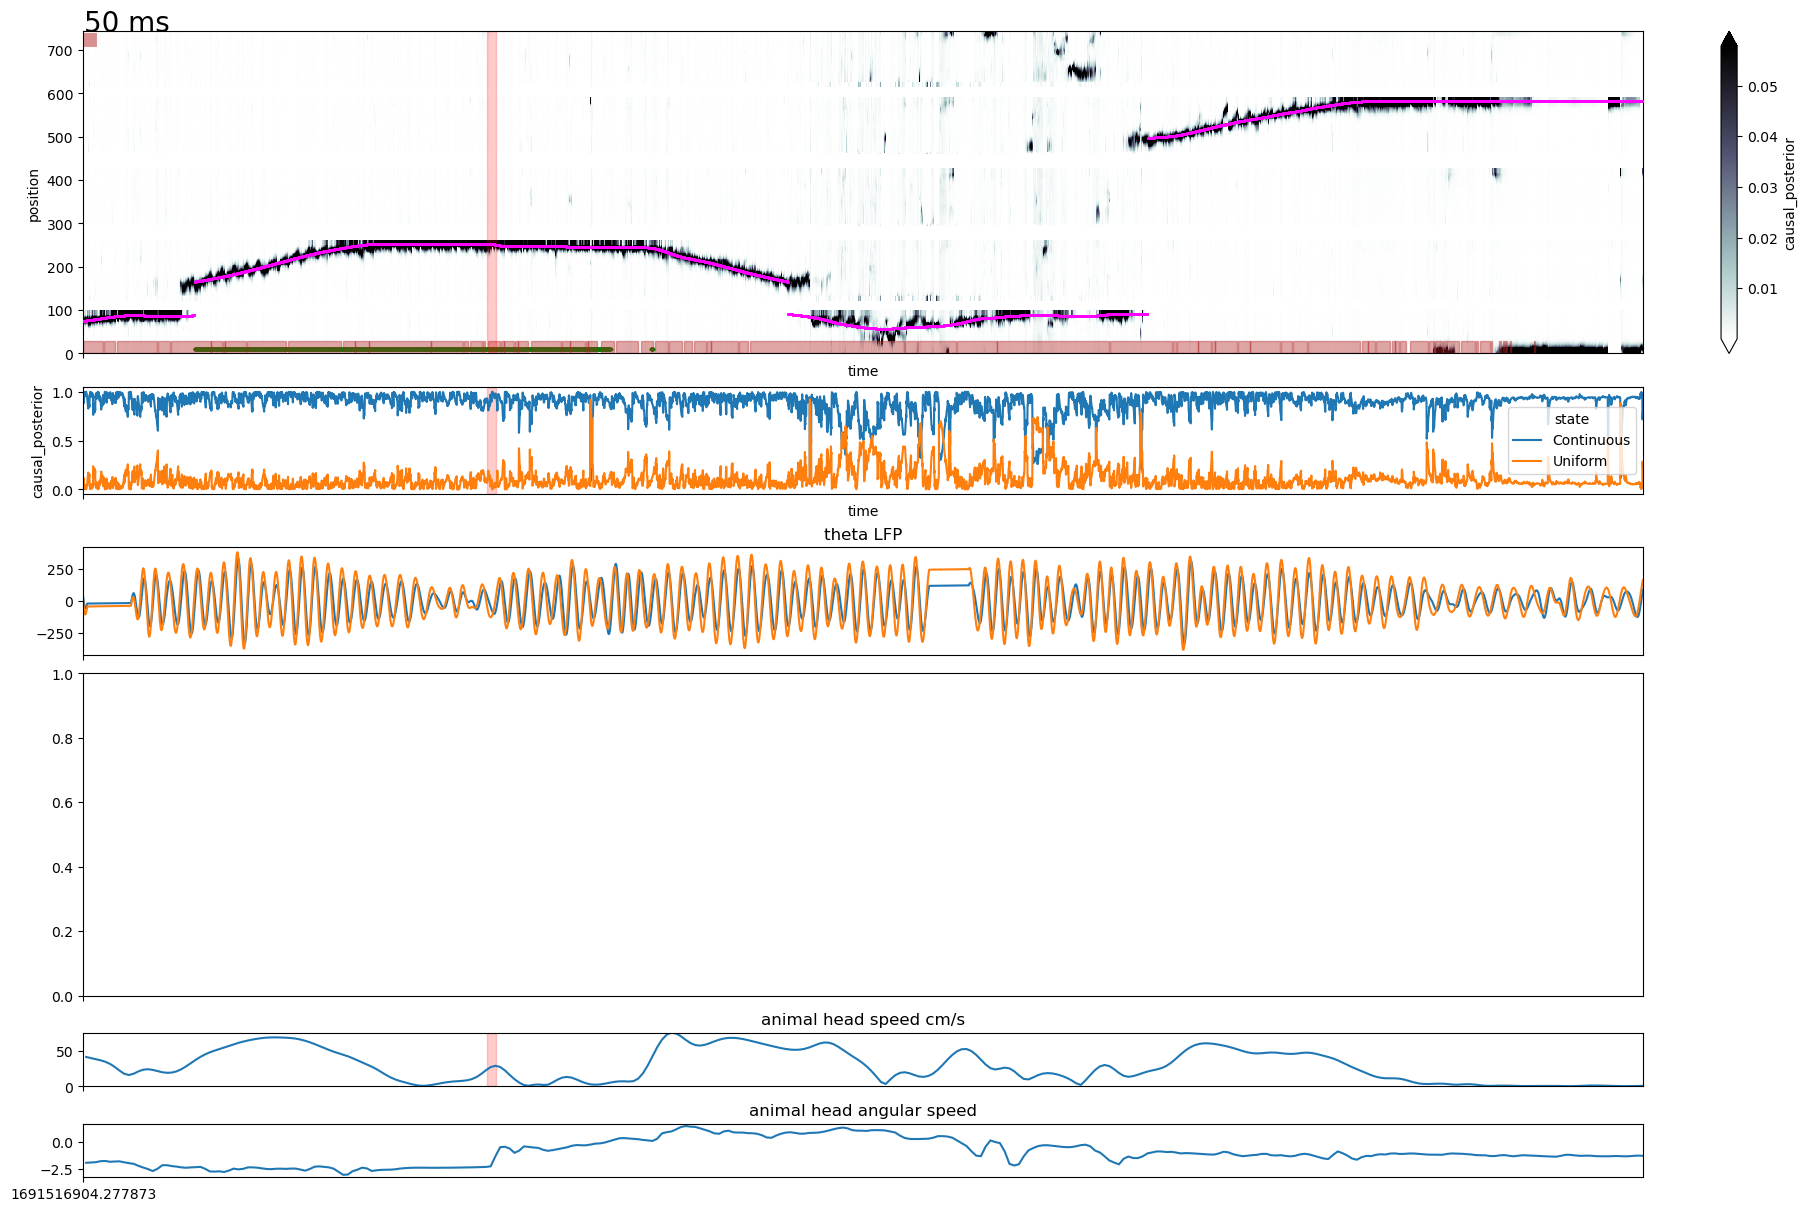

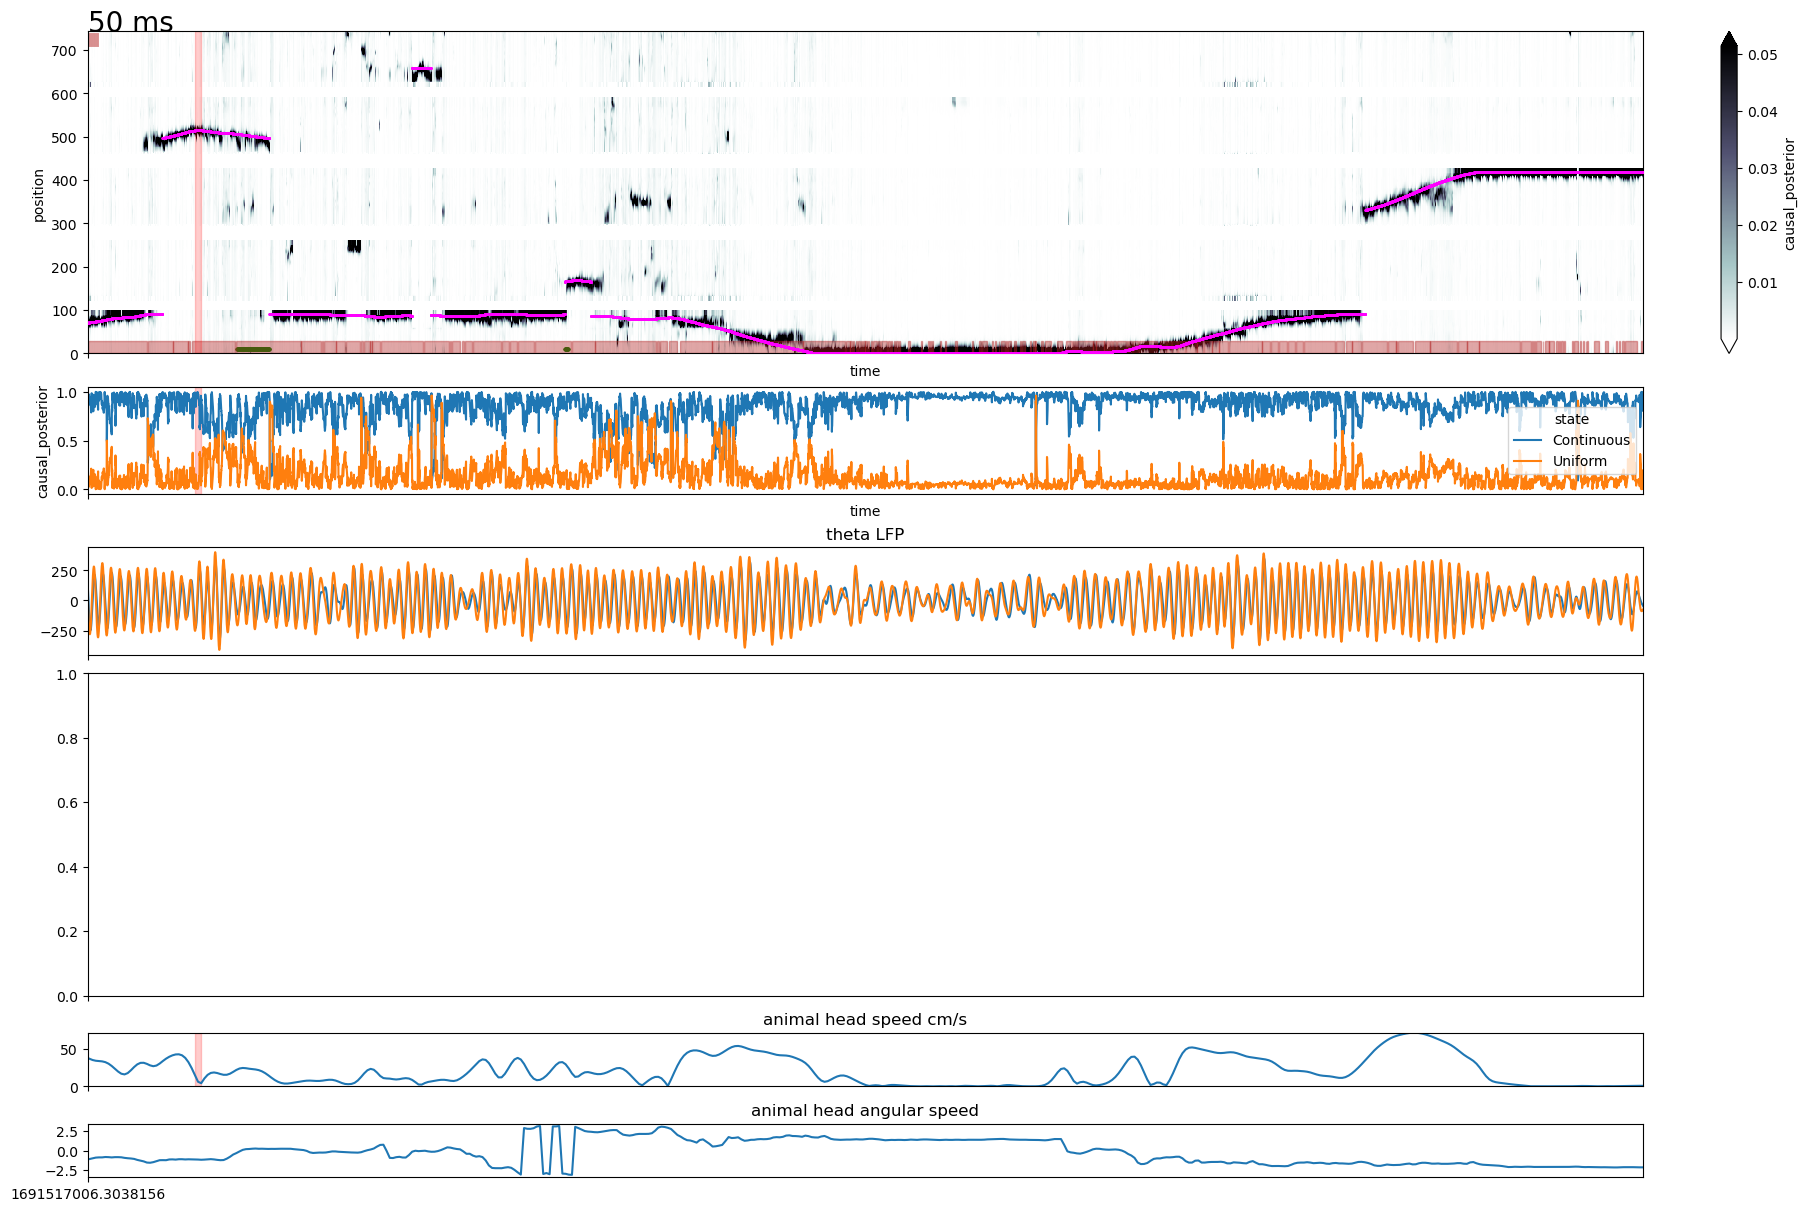

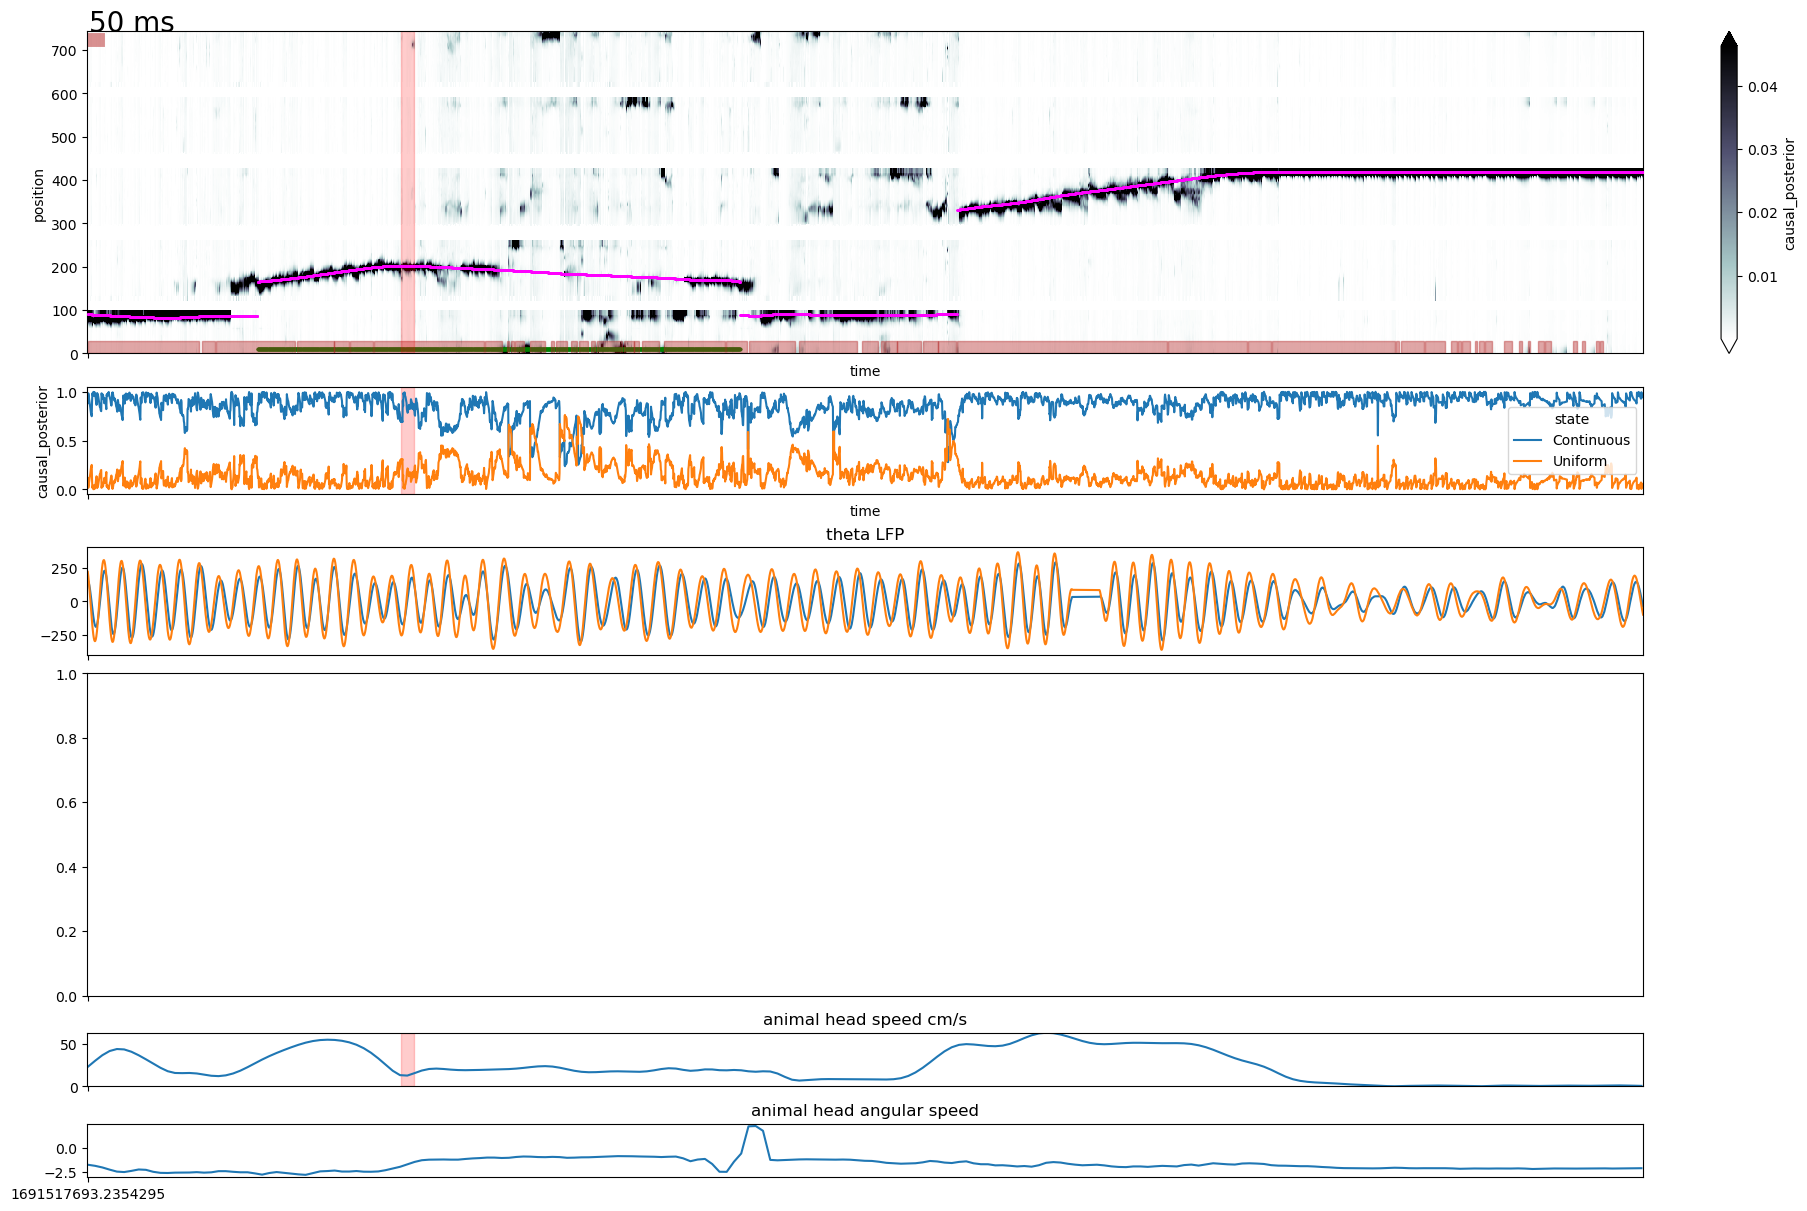

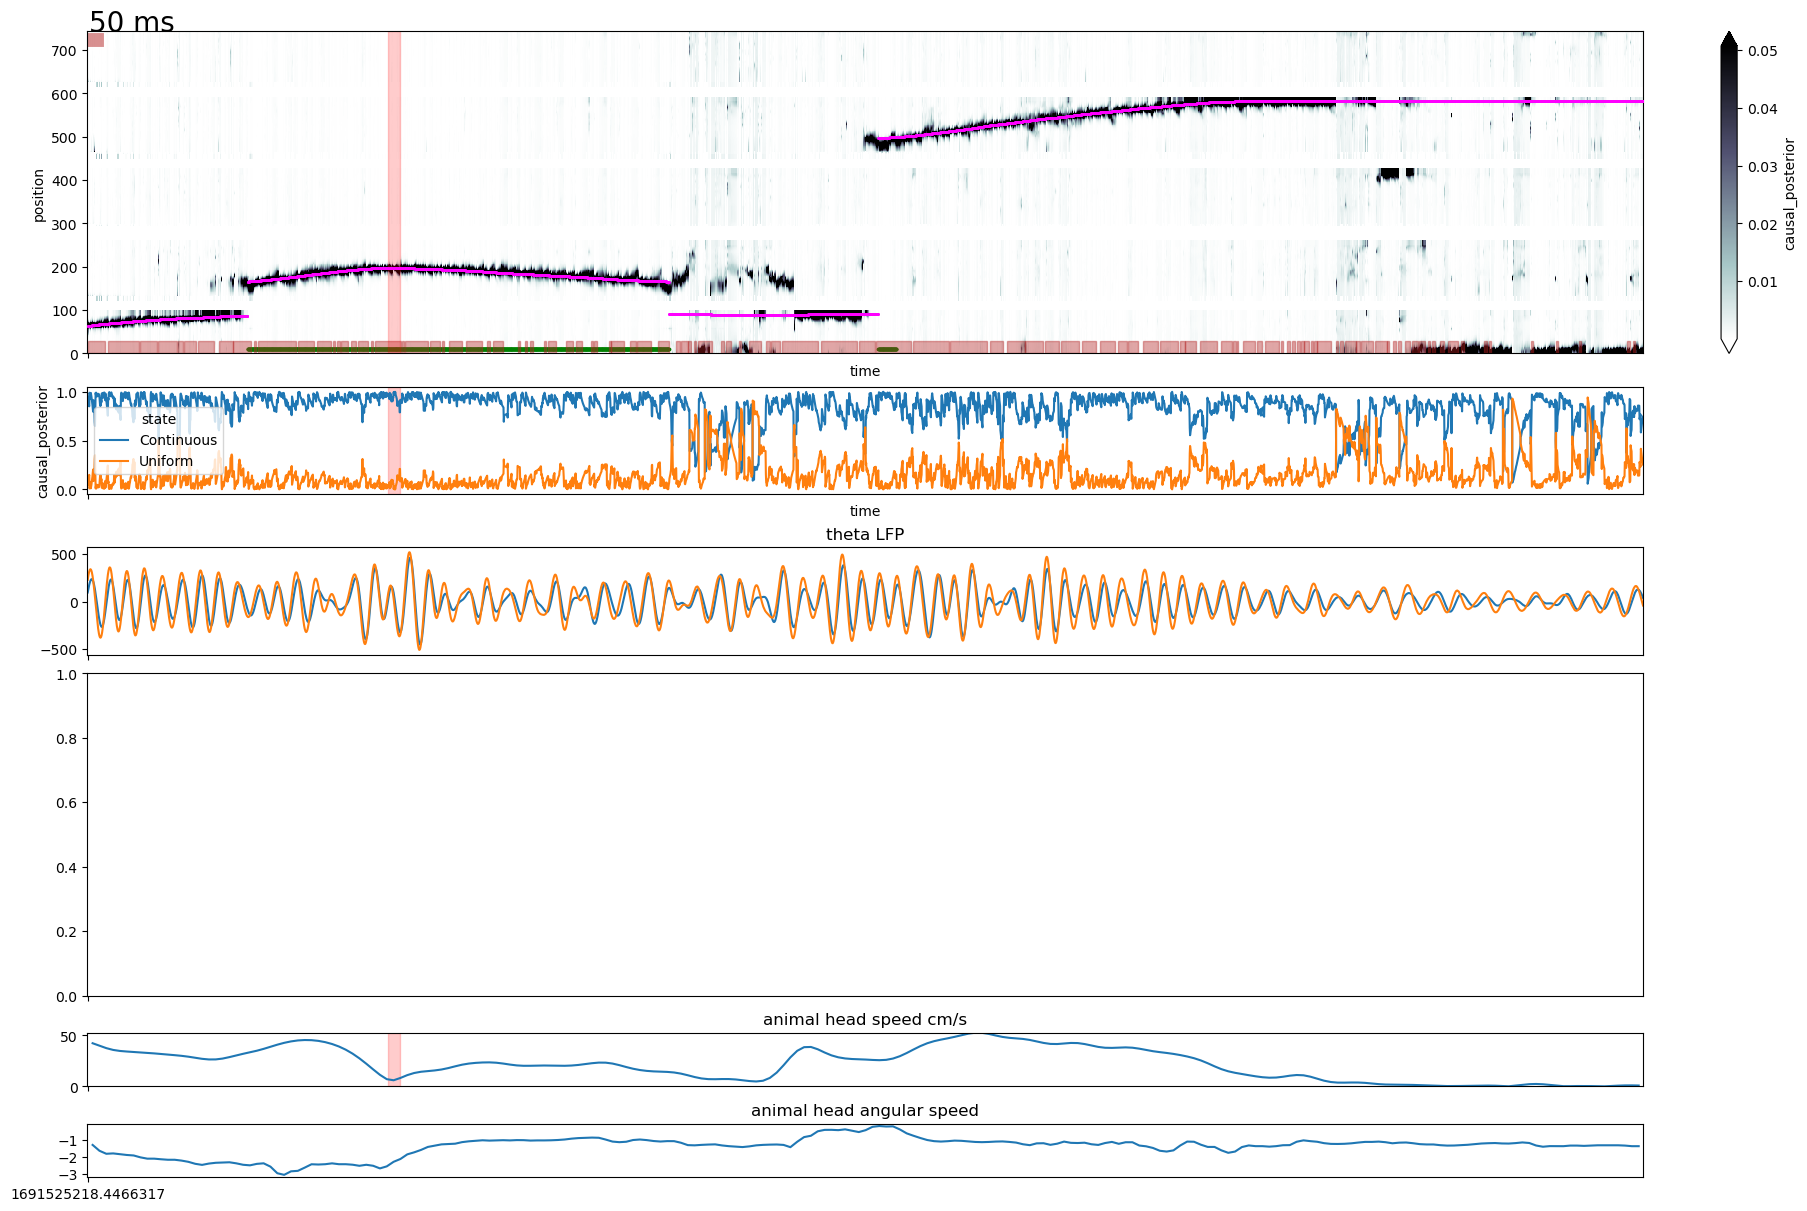

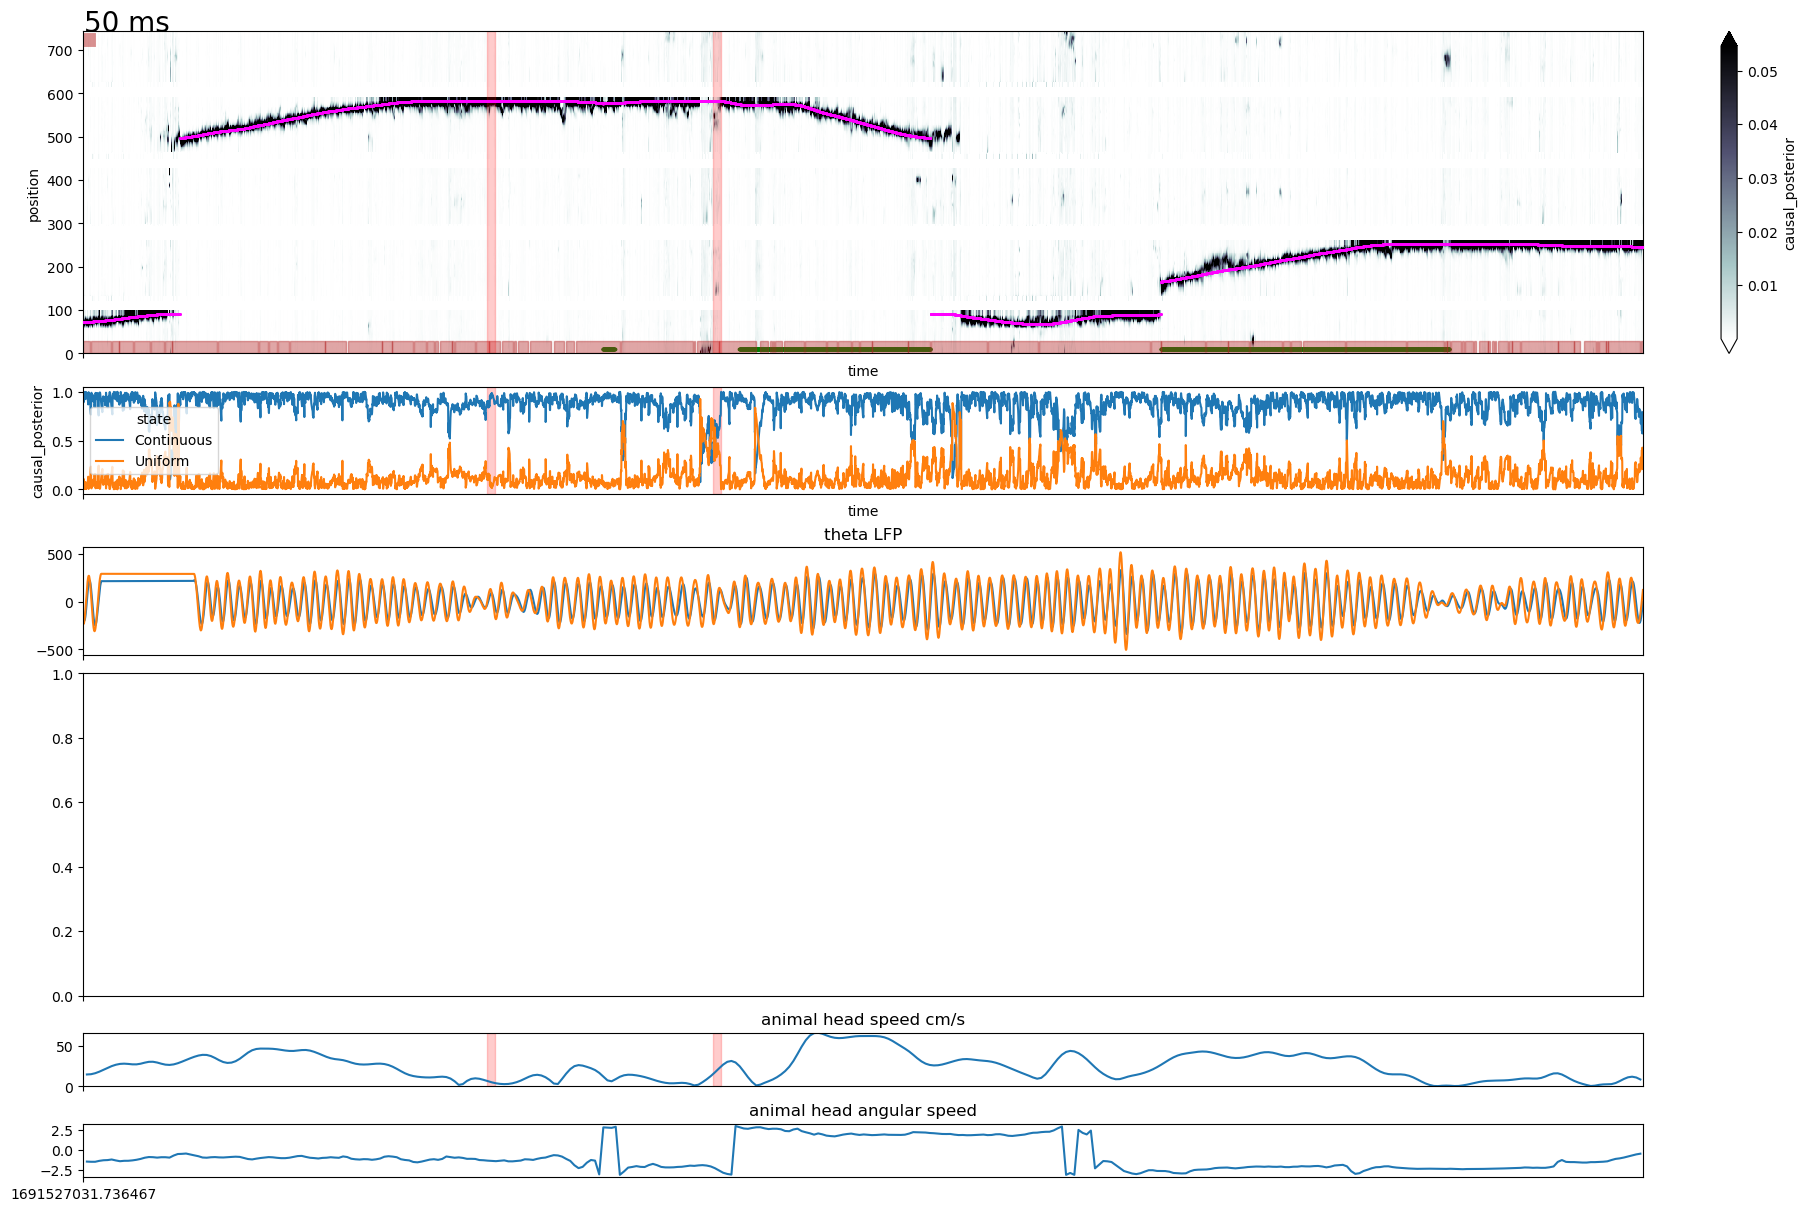

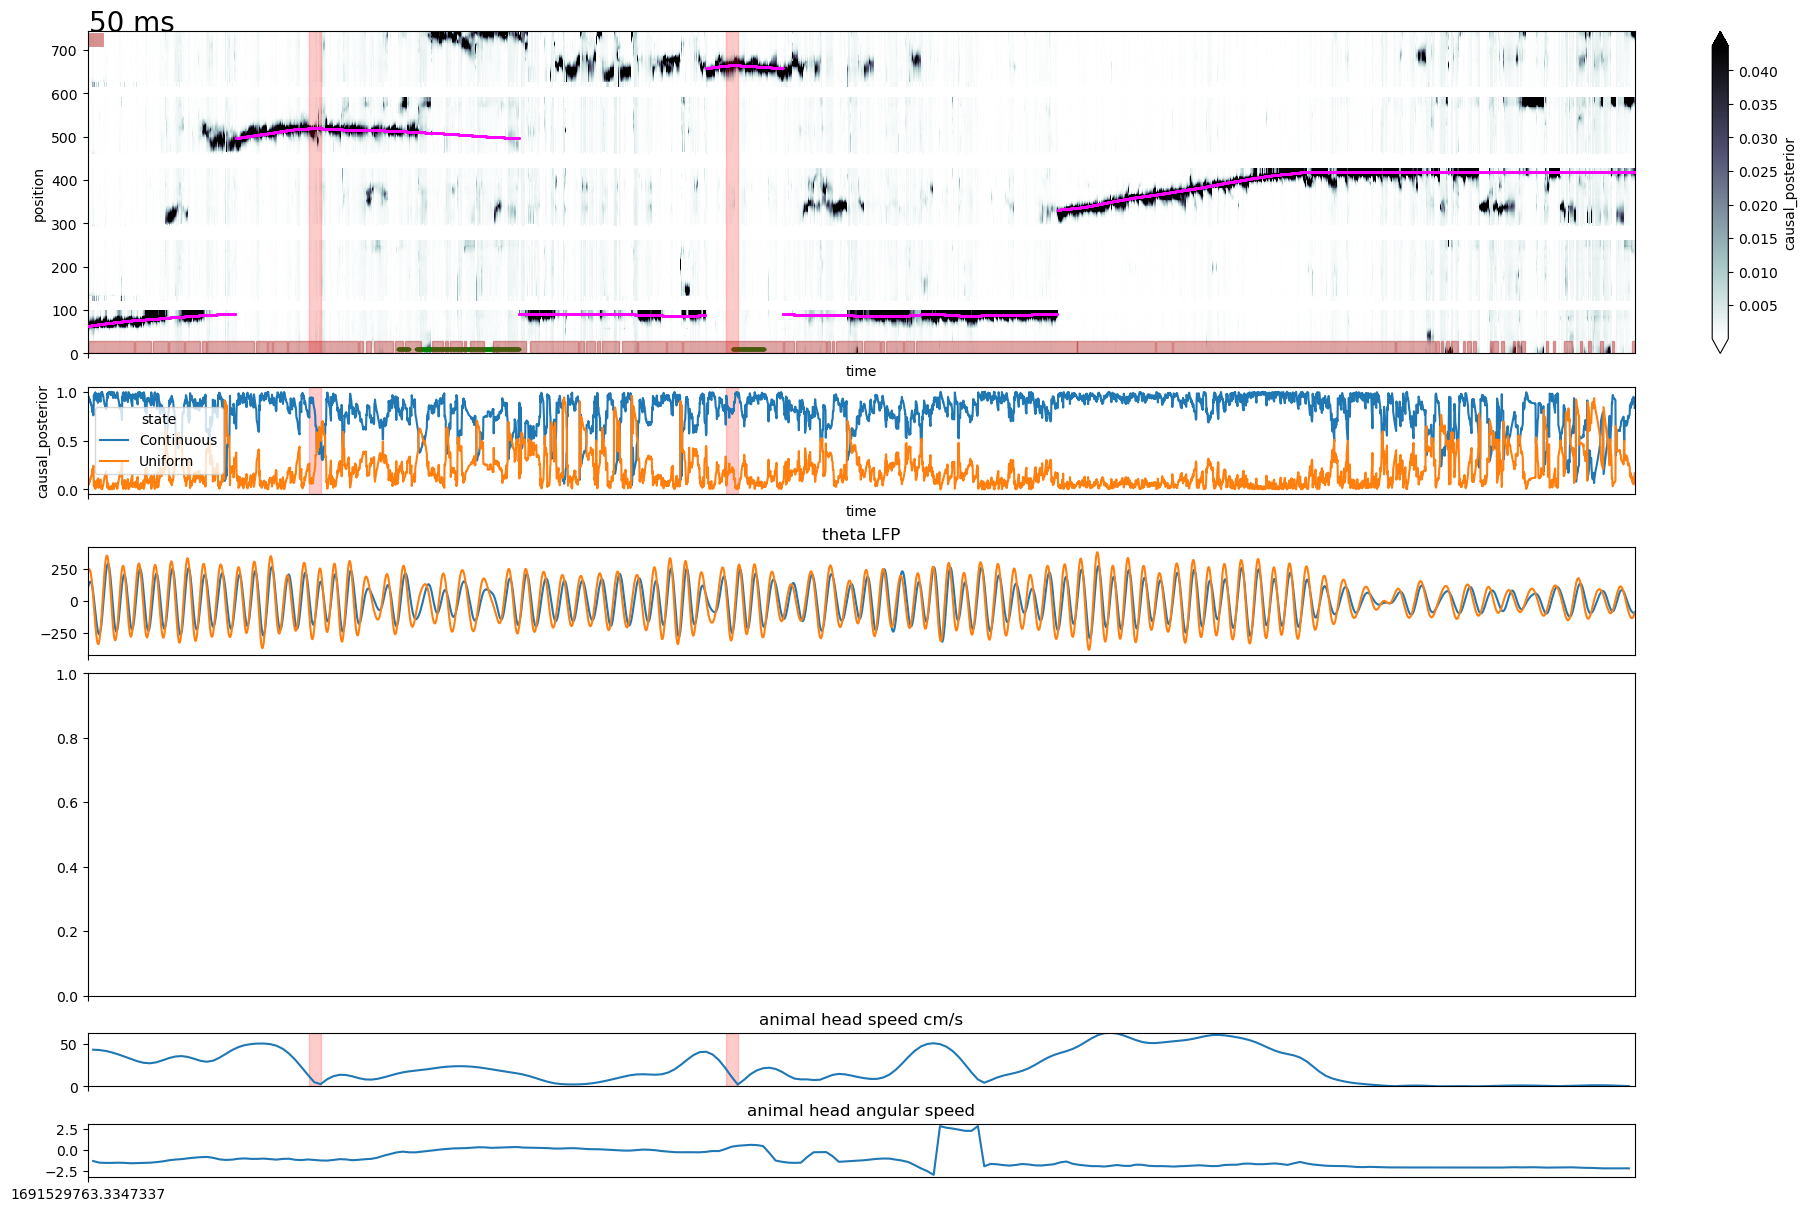

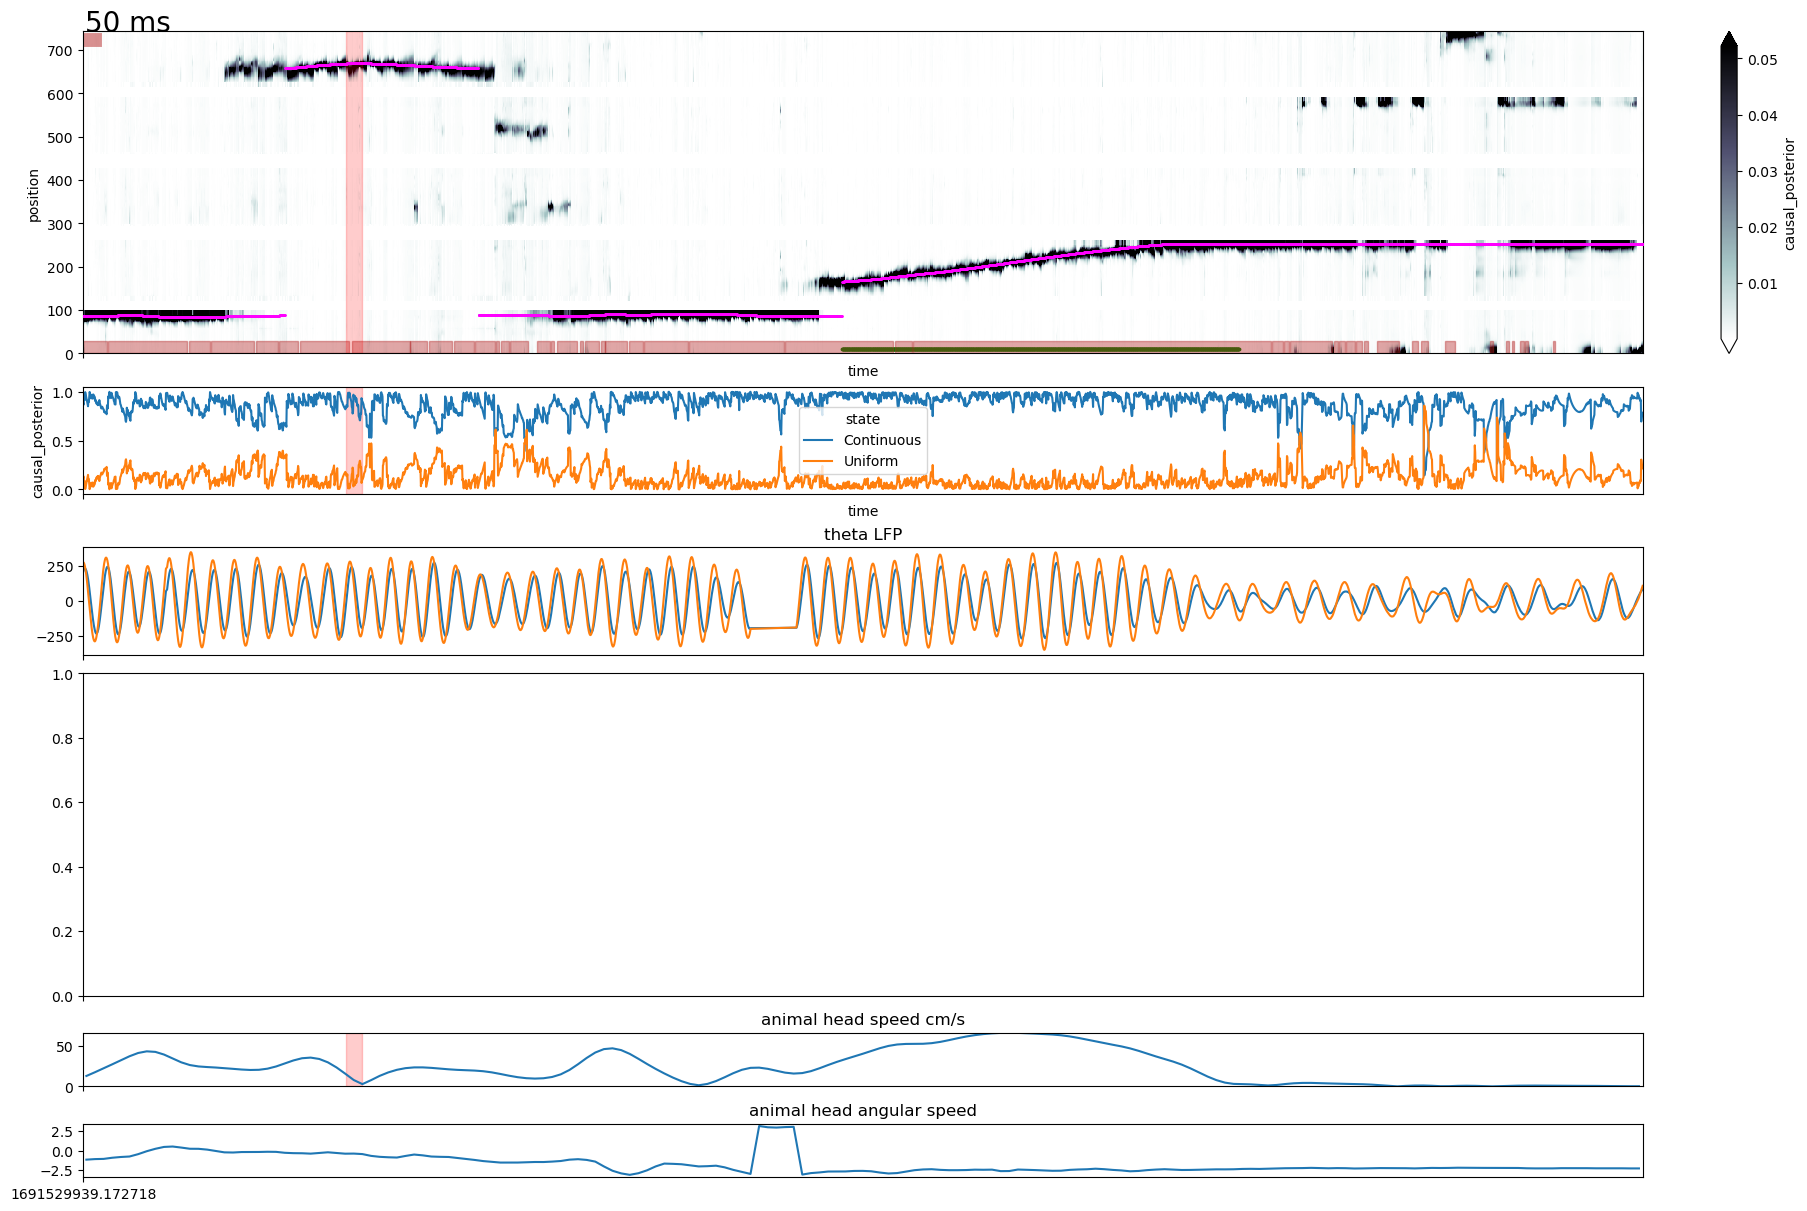

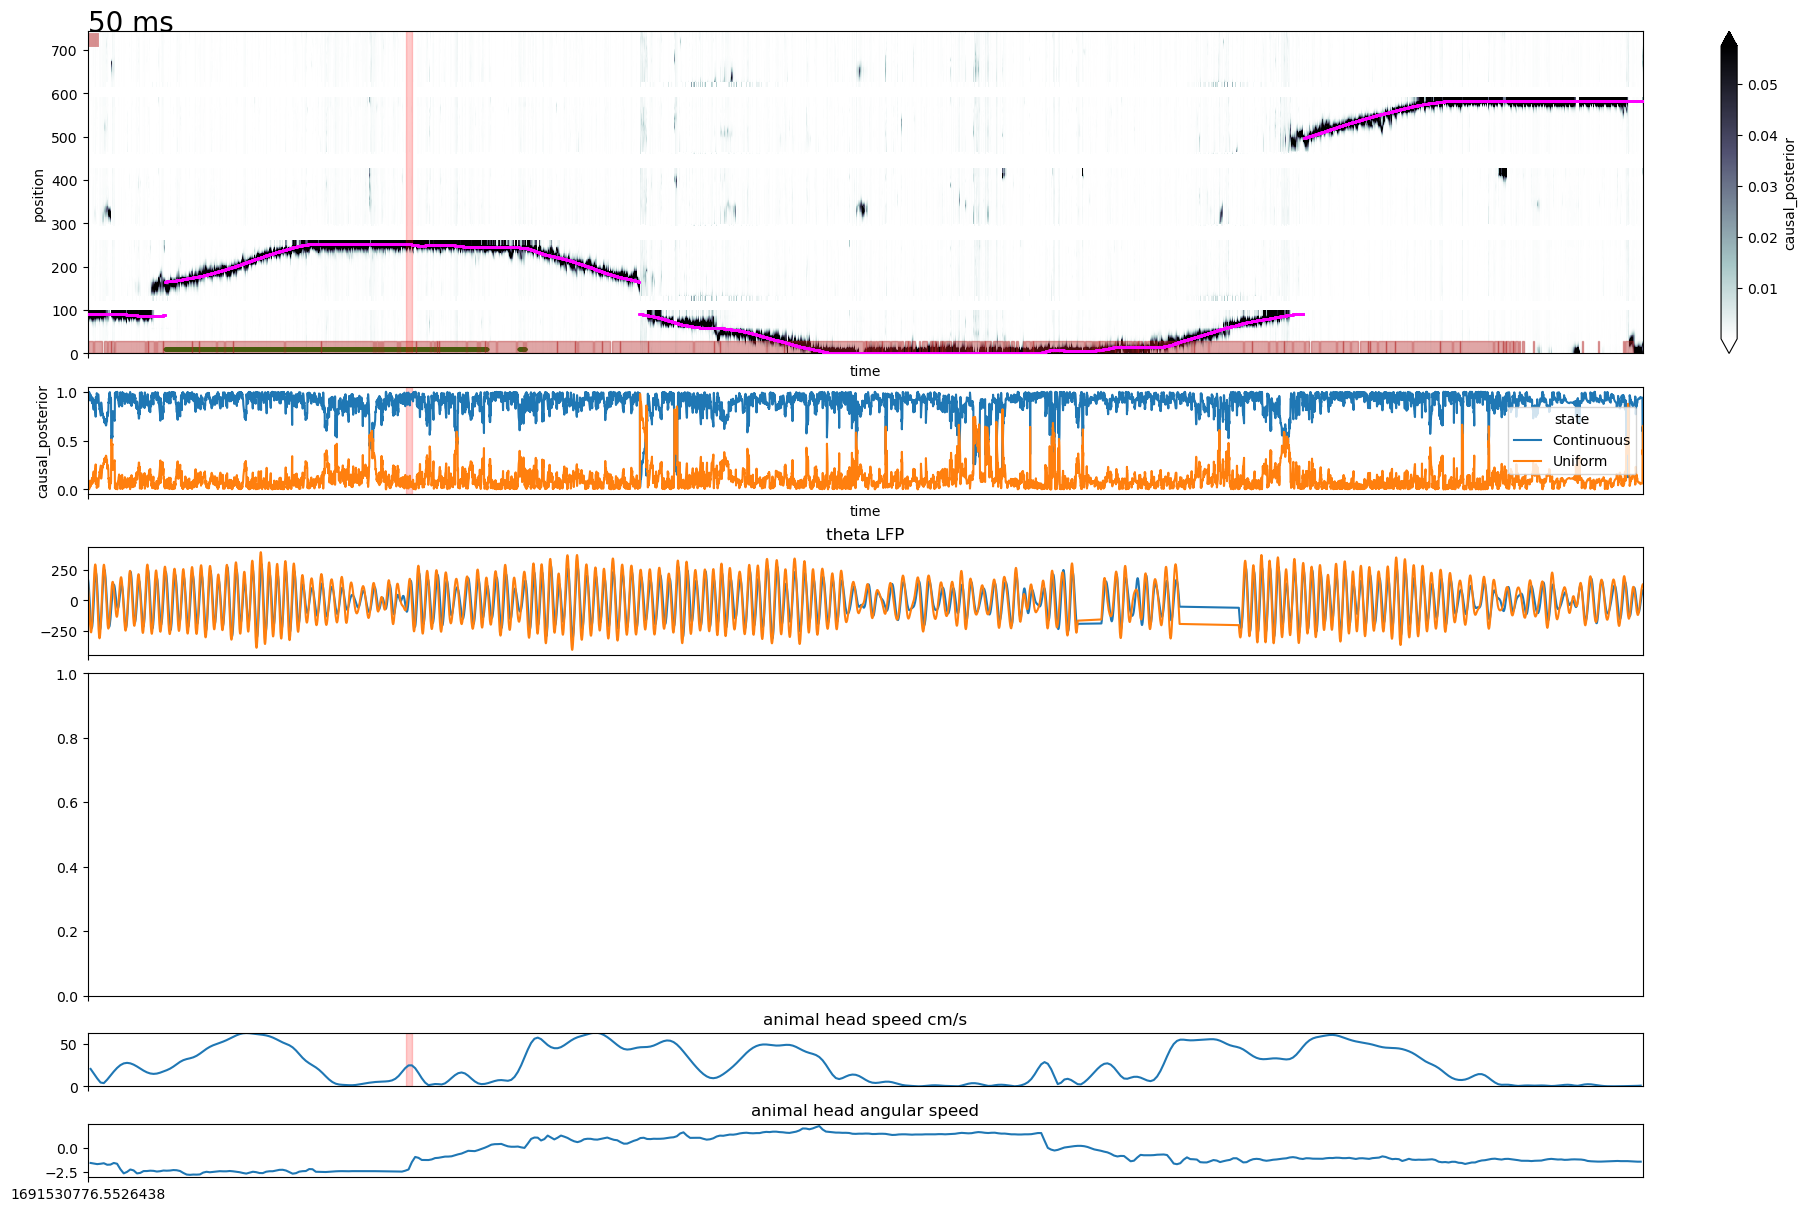

In [15]:
trials_days = find_trials_animal(animal,dates_to_plot,
                                 sorted_spikes = False,
                                 plot = True,
                                 plot_ripple = False,
                                 plot_spike = False,
                                 proportion_threshold = 0.1)

In [11]:
%debug

[12:42:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind.py(286)find_trials_session_plot()
    284             decode_options["likelihood"] = False
    285 
--> 286     (_,decode,head_speed,head_orientation,
    287             linear_position_df,lfp_df,theta_df,
    288             ripple_df,neural_df,mua_xr,mua_mean,mua_sd,spikeColInd) = load_epoch_data_wrapper(



ipdb>  (_,decode,head_speed,head_orientation,             linear_position_df,lfp_df,theta_df,             ripple_df,neural_df,mua_xr,mua_mean,mua_sd,spikeColInd) = load_epoch_data_wrapper(                 nwb_copy_file_name, session_name, position_name, decode_options,                 load_ripple_flag = plot_ripple, load_spike_flag = plot_spike)


[2025-10-30 12:42:12,860][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb
[2025-10-30 12:42:12,880][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb
[2025-10-30 12:42:12,885][WARNING]: Skipped checksum for file with hash: 67f67a4d-2f48-0841-44a7-9f6e498af76a, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_CLPY31LARI.nwb
[2025-10-30 12:42:12,921][WARNING]: Skipped checksum for file with hash: f1492a68-73f4-618b-6a87-46d60acfcdd5, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_K7DGKEC5W7.nwb
[2025-10-30 12:42:12,944][WARNING]: Skipped checksum for file with hash: f1492a68-73f4-618b-6a87-46d60acfcdd5, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_K7DGKEC5W7.nwb
[2025-10-30 12:42:12,952][WARNING]: Skipped checksum for file with hash: f1

epoch name 02_Seq2Session1
epoch_pos_name pos 1 valid times


[2025-10-30 12:42:13,095][WARNING]: Skipped checksum for file with hash: ce7fc179-16c6-d8c6-6e3d-c581ec1650c3, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_AQT5JX09DR.nwb
[2025-10-30 12:42:13,115][WARNING]: Skipped checksum for file with hash: ce7fc179-16c6-d8c6-6e3d-c581ec1650c3, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_AQT5JX09DR.nwb
[2025-10-30 12:42:13,121][WARNING]: Skipped checksum for file with hash: ce7fc179-16c6-d8c6-6e3d-c581ec1650c3, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_AQT5JX09DR.nwb
[2025-10-30 12:42:59,653][WARNING]: Skipped checksum for file with hash: 91be3860-ffce-25e5-6e5c-f5524268e5c1, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_2S2VNKU5MI.nwb
[2025-10-30 12:42:59,675][WARNING]: Skipped checksum for file with hash: 91be3860-ffce-25e5-6e5c-f5524268e5c1, and path: /stelmo/nwb/analysis/julio20230805/julio20230805_2S2VNKU5MI.nwb
[2025-10-30 12:42:59,681][WARNING]: Skipped checksum for file with hash: 91

ipdb>  exit


In [ ]:
# Examples to plot

# Julio 20230802 Seq2Session3 trial 69, the second one
# Julio 20230803 Seq2Session5 trial 9, also remote

# Molly 20220418 Seq2Session3 trial 39
# Molly 20220418 Seq2Session3 trial 53
# Molly 20220418 Seq2Session4 trial 9
# Molly 20220418 Seq2Session4 trial 32
# Molly 20220418 Seq2Session5 trial 17 **  good
# Molly 20220418 Seq2Session5 trial 22 maybe
# Molly 20220418 Seq2Session5 trial 28 maybe

# Lewis 20240108 Rev2Session1 trial 44
# Lewis 20240108 Rev2Session1 trial 48
# Lewis 20240108 Rev2Session1 trial 60
# Lewis 20240108 Rev2Session1 trial 67
# Lewis 20240108 Rev2Session2 trial 10
# Lewis 20240108 Rev2Session2 trial 18
# Lewis 20240108 Rev2Session2 trial 21
# Lewis 20240108 Rev2Session2 trial 32
# Lewis 20240108 Rev2Session2 trial 58
# Lewis 20240108 Rev2Session2 trial 61
# Lewis 20240108 Rev2Session3 trial 39


# with remote representation
# (not change of mind itself) Molly 20220418 Seq2Session2, the last trial
# Julio 20230803 Seq2Session4 trial 51
# Julio 20230803 Seq2Session5 trial 9, also front
# Julio 20230803 Seq2Session6 trial 13
# Julio 20230803 Seq2Session6 trial 52
# Julio 20230809 Seq2Session1 trial 26

# Molly 20220418 Seq2Session5 trial 34
# Lewis 20240108 Rev2Session2 trial 51
# Lewis 20240108 Rev2Session3 trial 43


